# Alumni RAG Agent 
CMU Africa Alumni Tracking and Support System.

# Environment Variables (.env.example)

In [ ]:
# MongoDB Atlas - Get from Atlas dashboard → Connect
MONGODB_URI=mongodb+srv://<username>:<password>@cluster.mongodb.net/?retryWrites=true&w=majority
# OpenAI - Get from CMU AI Gateway
OPENAI_API_KEY=sk-...
# LangSmith Tracing - Get from smith.langchain.com → Settings
LANGCHAIN_API_KEY=ls__...
LANGCHAIN_TRACING_V2=true
LANGCHAIN_PROJECT=alumni-rag-agent-hw2
# Email (Optional - dry_run mode works without these)
SMTP_HOST=smtp.gmail.com
SMTP_USER=your-email@gmail.com
SMTP_PASSWORD=your-app-password

# Data Pipeline & Schema
Input Data Flow
LinkedIn Scraping / Manual CSV → Python Ingestion Script → MongoDB Storage → Embedding Generation → Vector Index

# Alumni Profile Schema (Input)

In [ ]:
{
    "id": "A2023-001",
    "name": "John Doe",
    "email": "john.doe@example.com",
    "graduation_year": 2023,
    "program": "MSIT",
    "linkedin_url": "https://linkedin.com/in/johndoe",
    "current_position": "Data Engineer",
    "company": "TechCorp",
    "location": "Nairobi, Kenya",
    "skills": ["Python", "MongoDB", "Machine Learning"],
    "career_history": [
        {"title": "Junior Developer", "company": "StartupXYZ", "years": "2021-2023"},
        {"title": "Data Engineer", "company": "TechCorp", "years": "2023-present"}
    ]
}

# Stored Document Schema (MongoDB alumni_vectors collection)

In [ ]:
{
    "_id": ObjectId("..."),
    "content": "John Doe graduated from CMU Africa in 2023 with MSIT...",
    "embedding": [0.0123, -0.0456, ...],  # 1536 dimensions
    "metadata": {
        "alumni_id": "A2023-001",
        "doc_type": "profile",  # profile | interaction | policy
        "graduation_year": 2023,
        "program": "MSIT",
        "chunk_id": 0
    }
}

# Retrieval Output Schema

In [ ]:
# vector_store.similarity_search("fintech experience") returns:
[
    Document(
        page_content="John Doe works at TechCorp as a Data Engineer...",
        metadata={"alumni_id": "A2023-001", "doc_type": "profile"}
    ),
    Document(
        page_content="Jane Smith recently joined PayStack in fintech...",
        metadata={"alumni_id": "A2023-015", "doc_type": "profile"}
    )
]

# src/agent.py - Main Agent Structure
Integrates the three modules using a ReAct reasoning loop:

In [ ]:
class AlumniAgent:
    """Main agent orchestrating retrieval, tools, and verification."""
    
    def __init__(self, config_path: str = "config.yaml"):
        # 1. Load configuration
        self.config = load_config(config_path)
        
        # 2. Initialize Retrieval Module (Memory)
        self.retrieval = AlumniVectorStore(
            mongodb_uri=os.environ["MONGODB_URI"],
            index_name="alumni_vector_index"
        )
        
        # 3. Initialize Tools (Actions)
        self.tools = {
            "linkedin_scraper": create_linkedin_tool(),
            "email_sender": create_email_tool(dry_run=True),
            "survey_tool": create_survey_tool()
        }
        
        # 4. Initialize Verification (Guardrails)
        self.verifier = GroundednessScorer()
        
        # 5. Create ReAct Agent
        self.react_agent = ReActAgent(
            retrieval_fn=self.retrieval.search,
            tools=self.tools,
            verify_fn=self.verifier.calculate_groundedness
        )
    
    def run(self, query: str) -> dict:
        """
        Execute query through ReAct loop.
        
        Loop: OBSERVE → REASON → DECIDE → ACT → VERIFY → RESPOND
        
        Decision Point: Agent chooses between:
        - RETRIEVAL_MODULE: Need context from alumni database
        - TOOL_MODULE: Need external action (email, scrape, etc.)
        """
        result = self.react_agent.run(query)
        return {
            "response": result["response"],
            "verification": result["verification"],
            "trace": result["trace"]  # For LangSmith
        }

# Tools


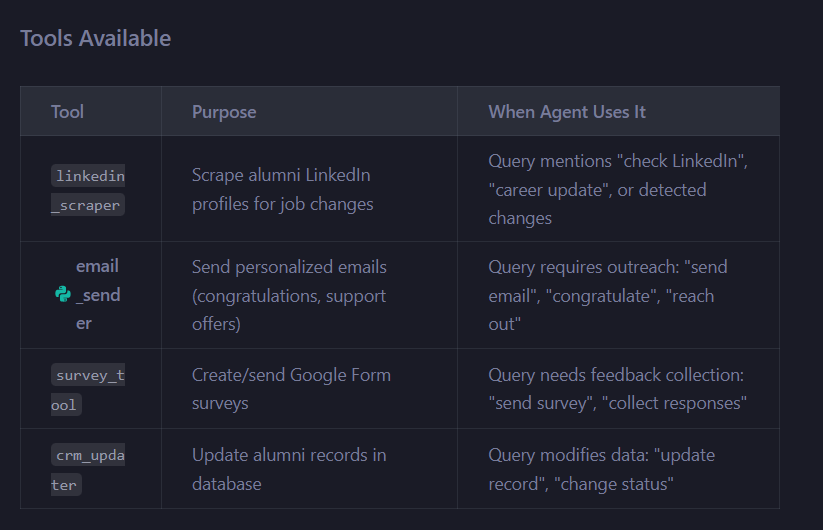

# Tool Selection Logic (in ReAct loop)

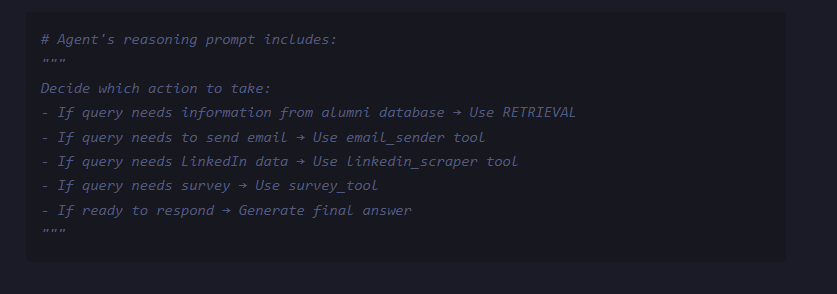

# Verification with Langsmith

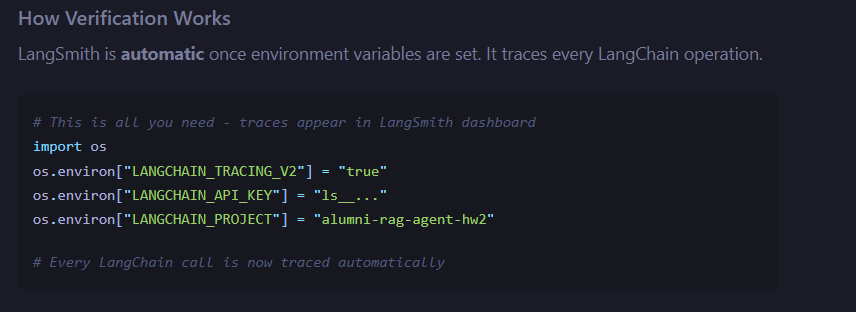

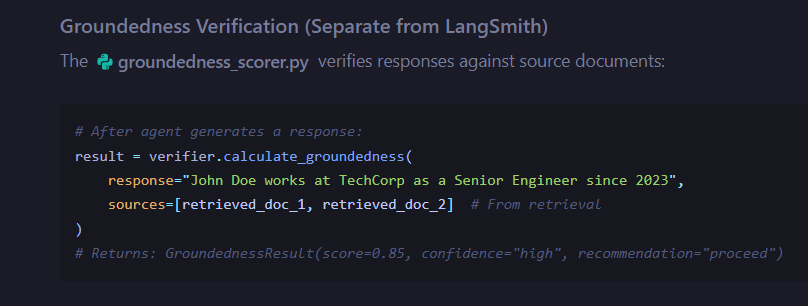

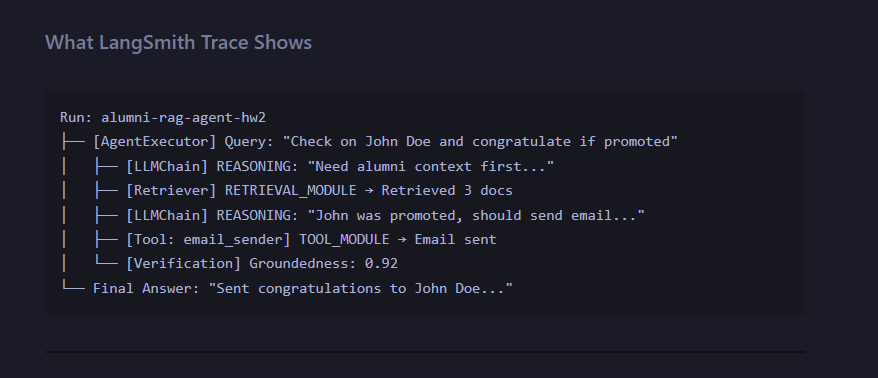

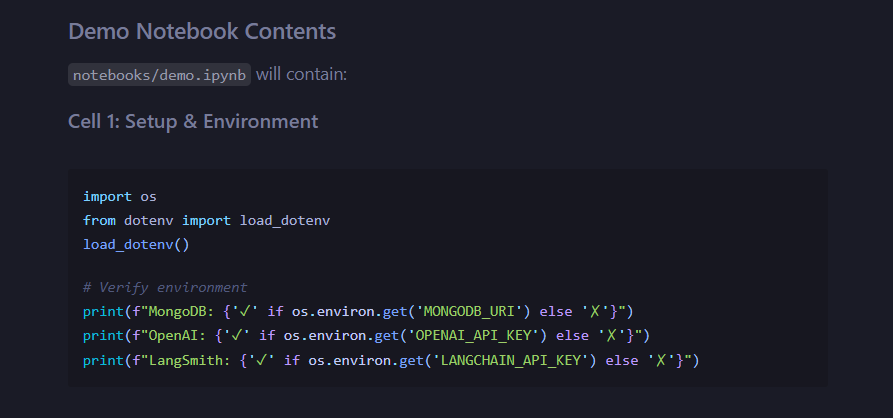

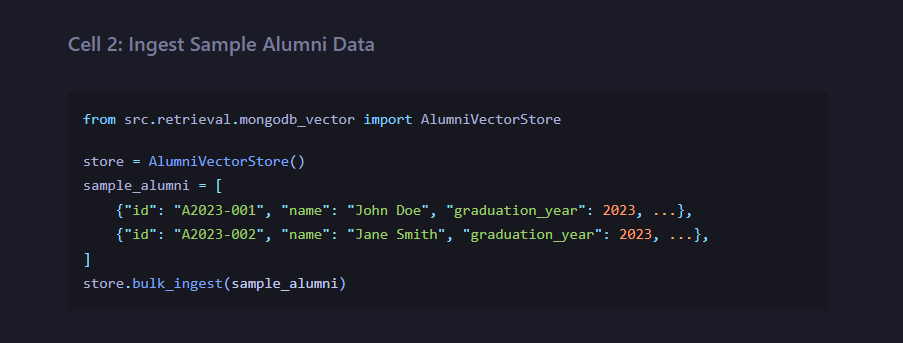

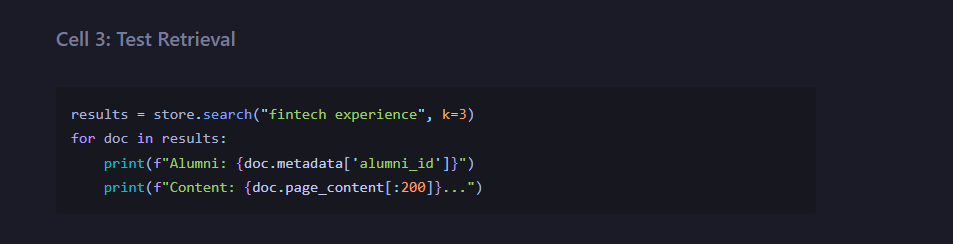

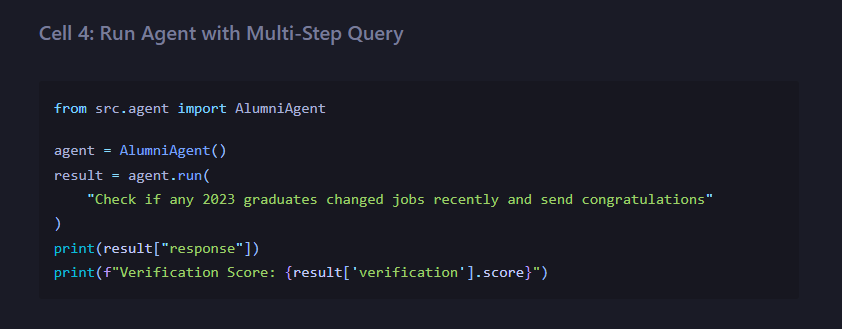

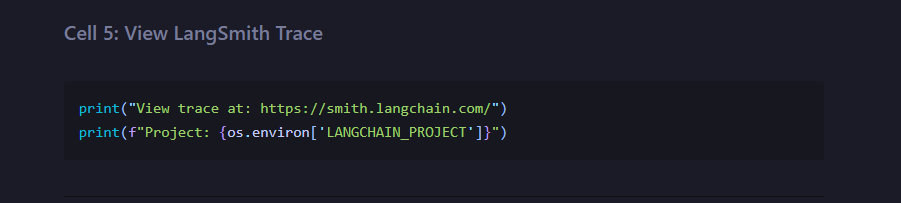